In [55]:
import numpy as np
from numpy.typing import NDArray
from warnings import warn, catch_warnings
from collections import Counter, defaultdict
from IPython.core.debugger import set_trace
from random import sample
%matplotlib inline
import matplotlib.pyplot as plt

In [56]:
def SuppressWarning(func):
    def wrapper(*args):
        with catch_warnings(action='ignore'):
            func(*args)
    return wrapper

### Basic Player
Implents K-Nearest Neighbors

Player:
* Has a policy, either null or complete
* Complete policies can be polled - get 20/100 random samples from policy, for example.
* Incomplete policies can be made complete via a "learning algorithm"
* All players can see "the world", as polling a complete policy is providing groudning examples to a new generation.
* Initial player (P0) has a "perfect" policy
* P1 polls P0, and then learns a policy from the one-shot polling.
* P0 is retired, P2 is created, and P1 is polled.

In [57]:
class Player:
    def __init__(self, policy: NDArray = None, n_signals: int = 2, n_states: int = 100):
        self.policy = policy
        self.signals = n_signals
        self.states = n_states

    def poll(self, n_samples: int = -1):
        # randomly polls policy across all "certain" states
        assert self.policy is not None

        # iron out how many samples to take
        if n_samples == -1:
            # try to take 20%
            n_samples = len(self.policy) // 5
            # if 20% can't possible sample each bucket, try.
            if n_samples < self.signals:
                n_samples = self.signals

        valid_moves = []
        groups = defaultdict(list)
        for i in range(self.states):
            group = self.policy[i]
            if group == 0:
                continue
            move = (i, group)
            valid_moves.append(move)
            groups[group].append(move)
        
        examples = sample(valid_moves, n_samples)

        return examples
    
    def learn(self, examples, k_neighbors):
        # learns policy from examples
        # ideally, we extend Player and override this method 
        # for each learning algorithm we want to implement
        if self.policy is not None:
            warn("This player already has a policy! Be aware, this will overwrite it.")

        # do the learning
        working_policy = np.zeros(self.states, dtype=np.int64)
        for state in range(self.states):
            n_examples = len(examples)
            k_neighbors = k_neighbors if n_examples > k_neighbors else n_examples
            working_policy[state] = self.predict(examples, state, k_neighbors)

        self.policy = working_policy


    def predict(self, examples, state, k_neighbors=5):
        # I'm going to implement a basic KNN
        distance = []
        for point_group in examples:
            point, group = point_group
            if isinstance(point, np.int64):
                dist = abs(state-point)
            else:
                # implement distance function for cartesian points
                dist = 0.5
            distance.append((dist, group))
        neighbors = sorted(distance)[:k_neighbors]
        c = Counter()
        for n in neighbors:
            c[n[1]] += 1
        return c.most_common(1)[0][0]
    
    def utility(self, init_policy):
        # compares (self) player's policy to given policy
        # returns utility score as ratio (0-1)
        assert self.policy is not None
        
        score = 0
        for state in range(self.states):
            if self.policy[state] == init_policy[state]:
                score += 1

        return score / self.states


* Can we evaluate utility based on the initial policy? - complete
* I need to debug the knn setup - Max

### Other Algorithms


In [68]:
from sklearn.neural_network import MLPClassifier

class MLPPlayer(Player):
    def __init__(self, *args, **kwargs):
        Player.__init__(self, *args, **kwargs)
        self.classifier = None
        self.threshold = 0.5

    @SuppressWarning
    def learn(self, examples, threshold=0.5):
        # train classifier
        clf = MLPClassifier((3,3), random_state=1, max_iter=10000)
        # (state, signal) - (0, 1), (24, 1), (59, 2)
        X = np.asarray([x[0] for x in examples]).reshape(-1, 1)
        y = np.asarray([x[1] for x in examples])
        
        clf.fit(X, y)

        # set_trace()

        # predict states for new policy
        working_policy = np.zeros(self.states, dtype=np.int64)
        for i in range(self.states):
            pred, prob = self.predict(clf, i)
            if prob >= threshold:
                working_policy[i] = pred
        
        # set_trace()
        
        # set policy
        self.policy = working_policy
        self.classifier = clf
        self.threshold = threshold


    def predict(self, model: MLPClassifier, state: int):
        probabilities = model.predict_proba(np.array([[state]]))
        most_confident = np.argmax(probabilities[0])
        prediction = most_confident + 1
        confidence = probabilities[0, most_confident]
        return prediction, confidence
    
    def graph_preds(self, filename=None):
        assert self.classifier is not None

        predictions = np.zeros((self.states, self.signals))
        for state in range(self.states):
            preds = self.classifier.predict_proba(np.array([[state]]))
            predictions[state] = preds

        # set_trace()
        # create legend
        labels = [f"Signal {i+1}" for i in range(self.signals)]
        labels.append("Threshold")

        plt.plot(range(1, self.states+1), predictions)
        plt.plot(range(1, self.states+1), [self.threshold] * self.states)
        plt.xlim(1, 100)
        plt.ylim(0, 1)
        plt.xlabel("State")
        plt.ylabel("Confidence")
        plt.legend(labels=labels)
        plt.grid(True)

        if isinstance(filename, str):
            plt.savefig(filename)
        else:
            plt.show()



### Games

In [59]:
# constants
generations = 3
inital_policy = np.array([1 if i < 50 else 2 for i in range(100)], dtype=np.int64)

In [60]:
P0 = Player(policy=inital_policy)
P1 = Player()
player_stack = [P0, P1]

# learn loop
for gen in range(generations):
    learner = player_stack.pop()
    teacher = player_stack.pop()

    examples = teacher.poll(40)
    learner.learn(examples, 3)

    next_gen = Player()
    player_stack.append(teacher)
    player_stack.append(learner)
    player_stack.append(next_gen)

    print("Completed generation " + str(gen))

# after learning, look in player stack for history.
# Can we plot overall utility per generation?
# You get 1 point for matching a state in the inital policy, 0 for missing.

Completed generation 0
Completed generation 1
Completed generation 2


In [69]:
P0 = MLPPlayer(policy=inital_policy)
P1 = MLPPlayer()
player_stack = [P0, P1]

# learn loop
for gen in range(generations):
    learner = player_stack.pop()
    teacher = player_stack.pop()

    examples = teacher.poll(40)
    learner.learn(examples, 0.75)

    next_gen = MLPPlayer()
    player_stack.append(teacher)
    player_stack.append(learner)
    player_stack.append(next_gen)

    print("Completed generation " + str(gen))

# after learning, look in player stack for history.

Completed generation 0
Completed generation 1
Completed generation 2


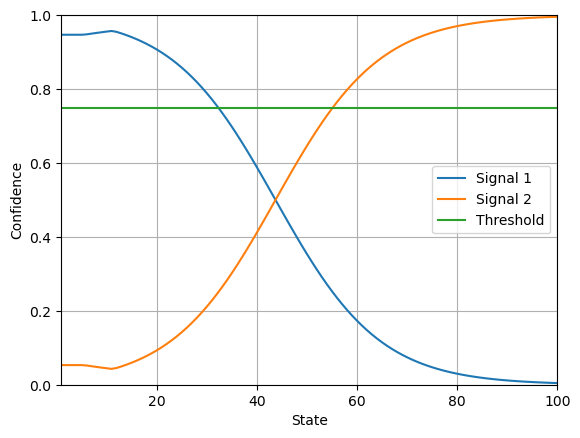

In [70]:
player_stack[1].graph_preds("foo.png")

In [71]:
player_stack[1].utility(inital_policy)

0.77

* Do any non-continuous group structures emerge over time? - Rose?
* can our threshold change over generations? (incr. over time) - Rose?
* Can we graph the precition score for each state to each signal for each generation? - complete

* Can we implement a player that uses logistic regression? - Max
* Are there any other learning algorithms that are applicable here? - Both